# Global Superstore — Exploratory Data Analysis (EDA)
 
Dataset: Global Superstore (Cleaned Version)  
Goal:Explore the data to find patterns, trends and business insights

 What This Notebook Covers:
1. Load the clean dataset
2. Sales performance overview
3. Sales trends over time
4. Category and product analysis
5. Regional and geographic analysis
6. Customer segment analysis
7. Discount vs profit analysis
8. Shipping analysis
9. Top 10 and bottom 10 analysis
10. Key business insights summary
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Chart styling ──────────────────────────────────────
plt.rcParams['figure.figsize']  = (14, 6)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['axes.grid']          = True
plt.rcParams['grid.alpha']         = 0.3
plt.rcParams['font.size']          = 11

# Colour palette
COLORS = ['#2196F3','#FF5722','#4CAF50','#FF9800',
          '#9C27B0','#00BCD4','#F44336','#8BC34A']
sns.set_palette(COLORS)

# ── Display settings ───────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── Create output folder for saving charts ────────────
os.makedirs('charts', exist_ok=True)

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [4]:
# ── Load the CLEAN dataset from Step 1 ────────────────
df = pd.read_csv('Global_Superstore_CLEAN.csv', encoding='latin-1')
# Re-convert date columns after loading from CSV
for col in ['order_date', 'ship_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print('✅ Clean dataset loaded')
print(f'   Rows    : {df.shape[0]:,}')
print(f'   Columns : {df.shape[1]}')
print(f'   Date range: {df["order_date"].min().date()} to {df["order_date"].max().date()}')
df.head()

✅ Clean dataset loaded
   Rows    : 9,994
   Columns : 35
   Date range: 2014-01-03 to 2017-12-30


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,sales_outlier_flag,profit_outlier_flag,order_year,order_month,order_month_name,order_quarter,order_quarter_label,order_day_of_week,order_week,shipping_days,profit_margin_pct,revenue_per_unit,is_discounted,profit_category
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,False,False,2016,11,November,4,Q4,Tuesday,45,3,16.00,130.98,False,Low Profit
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,True,True,2016,11,November,4,Q4,Tuesday,45,3,30.00,243.98,False,Medium Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,False,False,2016,6,June,2,Q2,Sunday,23,4,47.00,7.31,False,Low Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,True,True,2015,10,October,4,Q4,Sunday,41,7,-40.00,191.52,True,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,False,False,2015,10,October,4,Q4,Sunday,41,7,11.25,11.18,True,Low Profit


In [5]:
# ── Calculate key business metrics ────────────────────
total_sales      = df['sales'].sum()
total_profit     = df['profit'].sum()
total_orders     = df['order_id'].nunique()
total_customers  = df['customer_id'].nunique() if 'customer_id' in df.columns else 'N/A'
total_products   = df['product_id'].nunique()  if 'product_id'  in df.columns else 'N/A'
avg_order_value  = total_sales / total_orders
profit_margin    = (total_profit / total_sales) * 100
avg_discount     = df['discount'].mean() * 100 if 'discount' in df.columns else 0
avg_shipping     = df['shipping_days'].mean() if 'shipping_days' in df.columns else 0

print('=' * 55)
print('        📊 BUSINESS KPI SUMMARY')
print('=' * 55)
print(f'  Total Sales Revenue  : ${total_sales:>15,.2f}')
print(f'  Total Profit         : ${total_profit:>15,.2f}')
print(f'  Profit Margin        : {profit_margin:>14.1f}%')
print(f'  Total Orders         : {total_orders:>15,}')
print(f'  Total Customers      : {str(total_customers):>15}')
print(f'  Total Products       : {str(total_products):>15}')
print(f'  Avg Order Value      : ${avg_order_value:>15,.2f}')
print(f'  Avg Discount Given   : {avg_discount:>14.1f}%')
print(f'  Avg Shipping Days    : {avg_shipping:>14.1f}')
print('=' * 55)

        📊 BUSINESS KPI SUMMARY
  Total Sales Revenue  : $   2,297,200.86
  Total Profit         : $     286,397.02
  Profit Margin        :           12.5%
  Total Orders         :           5,009
  Total Customers      :             793
  Total Products       :            1862
  Avg Order Value      : $         458.61
  Avg Discount Given   :           15.6%
  Avg Shipping Days    :            4.0


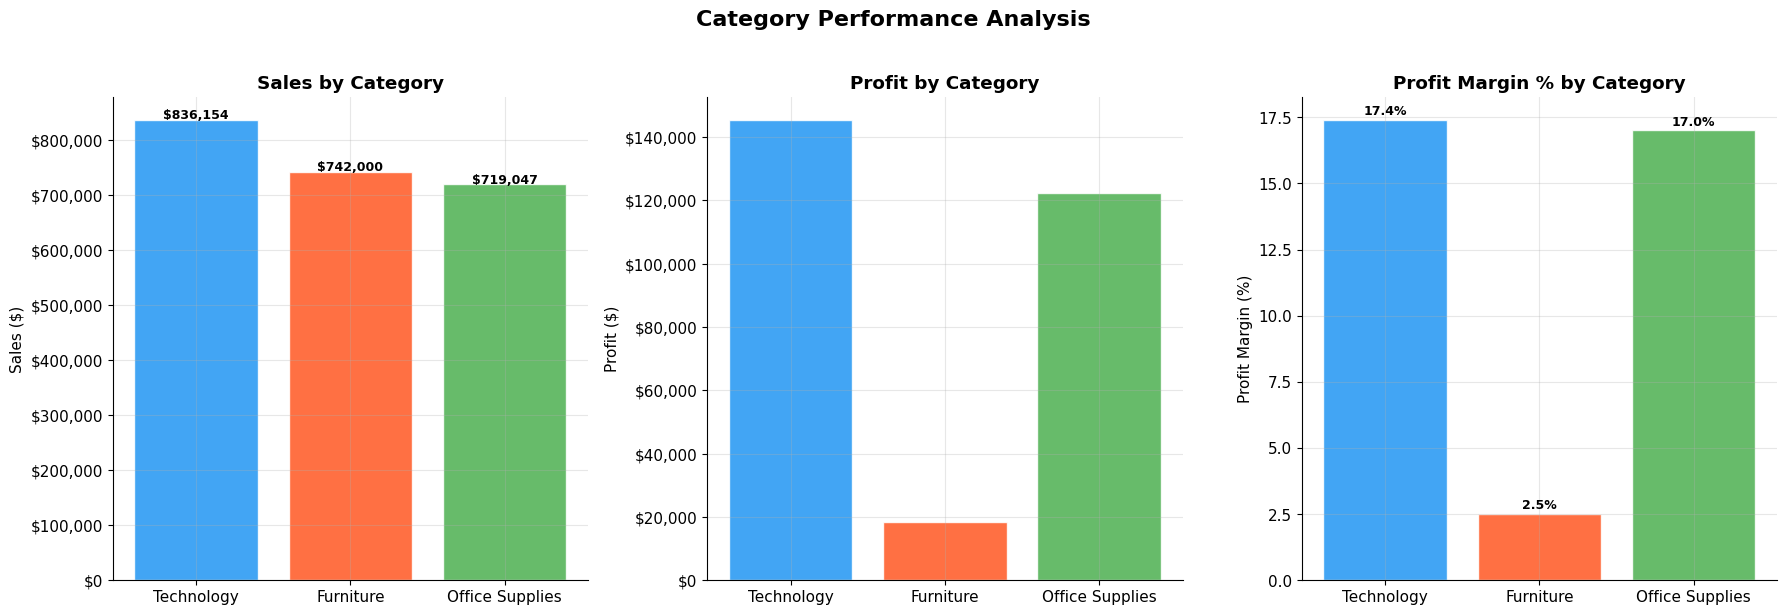


Category Summary:
       category      Sales     Profit  Orders  Profit Margin %
     Technology 836,154.03 145,454.95    1847            17.40
      Furniture 741,999.80  18,451.27    2121             2.50
Office Supplies 719,047.03 122,490.80    6026            17.00


In [6]:
# ── Sales and Profit by Category ──────────────────────
category = df.groupby('category').agg(
    Sales   = ('sales',  'sum'),
    Profit  = ('profit', 'sum'),
    Orders  = ('order_id', 'count')
).reset_index().sort_values('Sales', ascending=False)

category['Profit Margin %'] = (category['Profit'] / category['Sales'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sales by category
axes[0].bar(category['category'], category['Sales'],
            color=COLORS[:3], alpha=0.85, edgecolor='white')
axes[0].set_title('Sales by Category', fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for bar, val in zip(axes[0].patches, category['Sales']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Profit by category
axes[1].bar(category['category'], category['Profit'],
            color=COLORS[:3], alpha=0.85, edgecolor='white')
axes[1].set_title('Profit by Category', fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Profit margin by category
axes[2].bar(category['category'], category['Profit Margin %'],
            color=COLORS[:3], alpha=0.85, edgecolor='white')
axes[2].set_title('Profit Margin % by Category', fontweight='bold')
axes[2].set_ylabel('Profit Margin (%)')
for bar, val in zip(axes[2].patches, category['Profit Margin %']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Category Performance Analysis', fontsize=16,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/04_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCategory Summary:')
print(category.to_string(index=False))

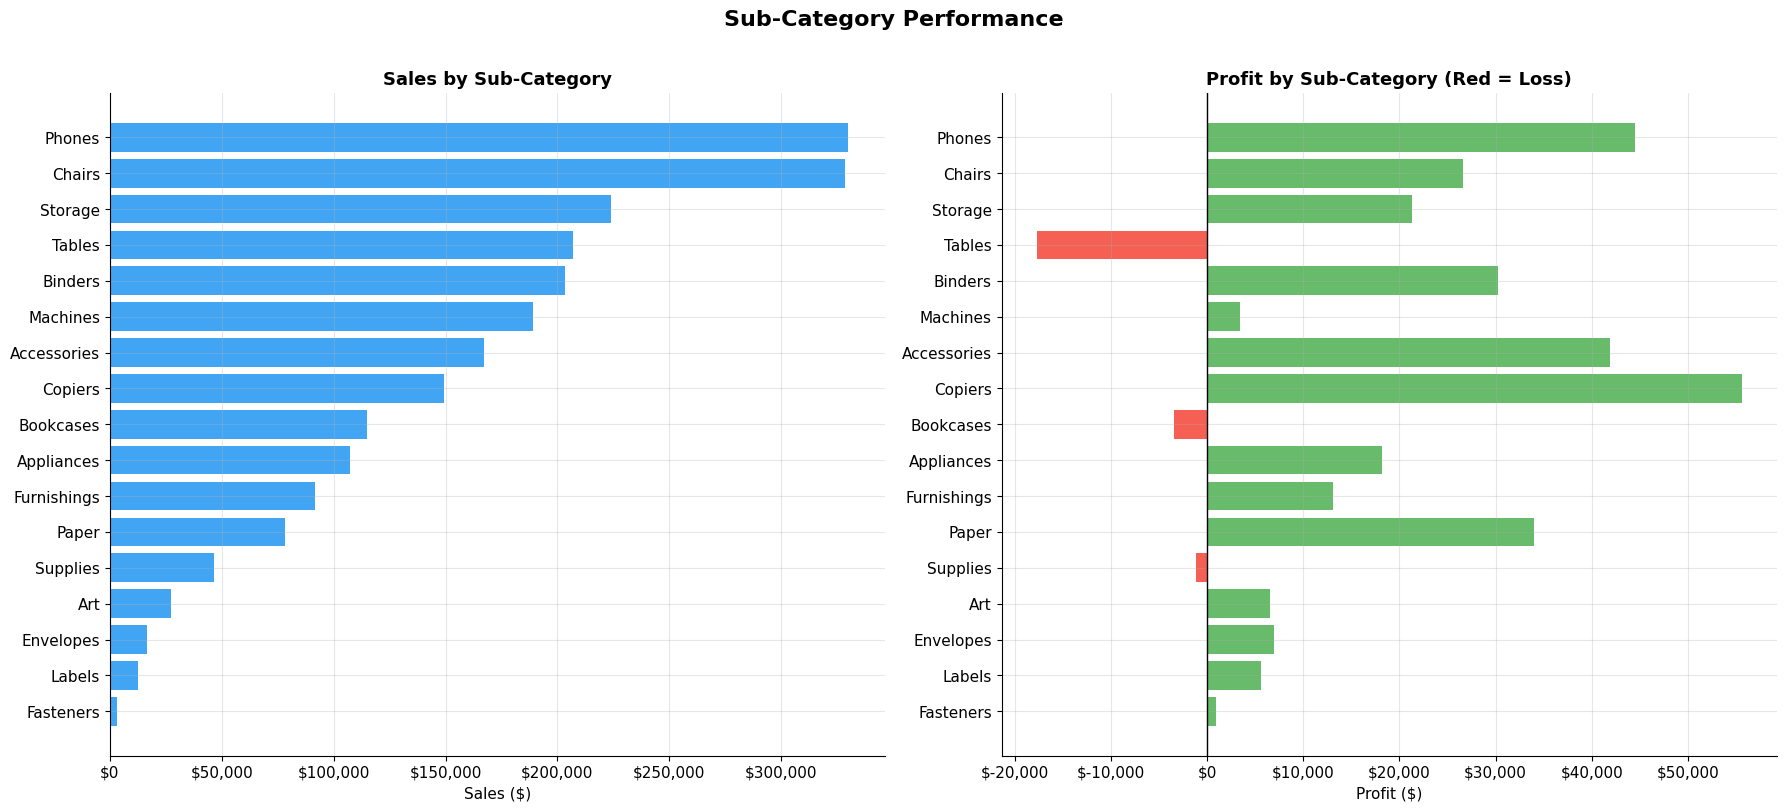


⚠️  Loss-making Sub-Categories:
sub_category      Sales     Profit  Profit Margin %
      Tables 206,965.53 -17,725.48            -8.60
   Bookcases 114,880.00  -3,472.56            -3.00
    Supplies  46,673.54  -1,189.10            -2.50


In [7]:
# ── Sales by Sub-Category ──────────────────────────────
sub_cat = df.groupby('sub_category').agg(
    Sales  = ('sales',  'sum'),
    Profit = ('profit', 'sum')
).reset_index().sort_values('Sales', ascending=True)

sub_cat['Profit Margin %'] = (sub_cat['Profit'] / sub_cat['Sales'] * 100).round(1)
colors_sub = ['#F44336' if p < 0 else '#4CAF50' for p in sub_cat['Profit']]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Sales horizontal bar
axes[0].barh(sub_cat['sub_category'], sub_cat['Sales'],
             color='#2196F3', alpha=0.85)
axes[0].set_title('Sales by Sub-Category', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Sales ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Profit horizontal bar — red = loss, green = profit
axes[1].barh(sub_cat['sub_category'], sub_cat['Profit'],
             color=colors_sub, alpha=0.85)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('Profit by Sub-Category (Red = Loss)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Profit ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.suptitle('Sub-Category Performance', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/05_subcategory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print loss-making sub-categories
losses = sub_cat[sub_cat['Profit'] < 0].sort_values('Profit')
if len(losses) > 0:
    print('\n⚠️  Loss-making Sub-Categories:')
    print(losses[['sub_category','Sales','Profit','Profit Margin %']].to_string(index=False))

REGIONAL GEOGRAPHIC ANALYSIS

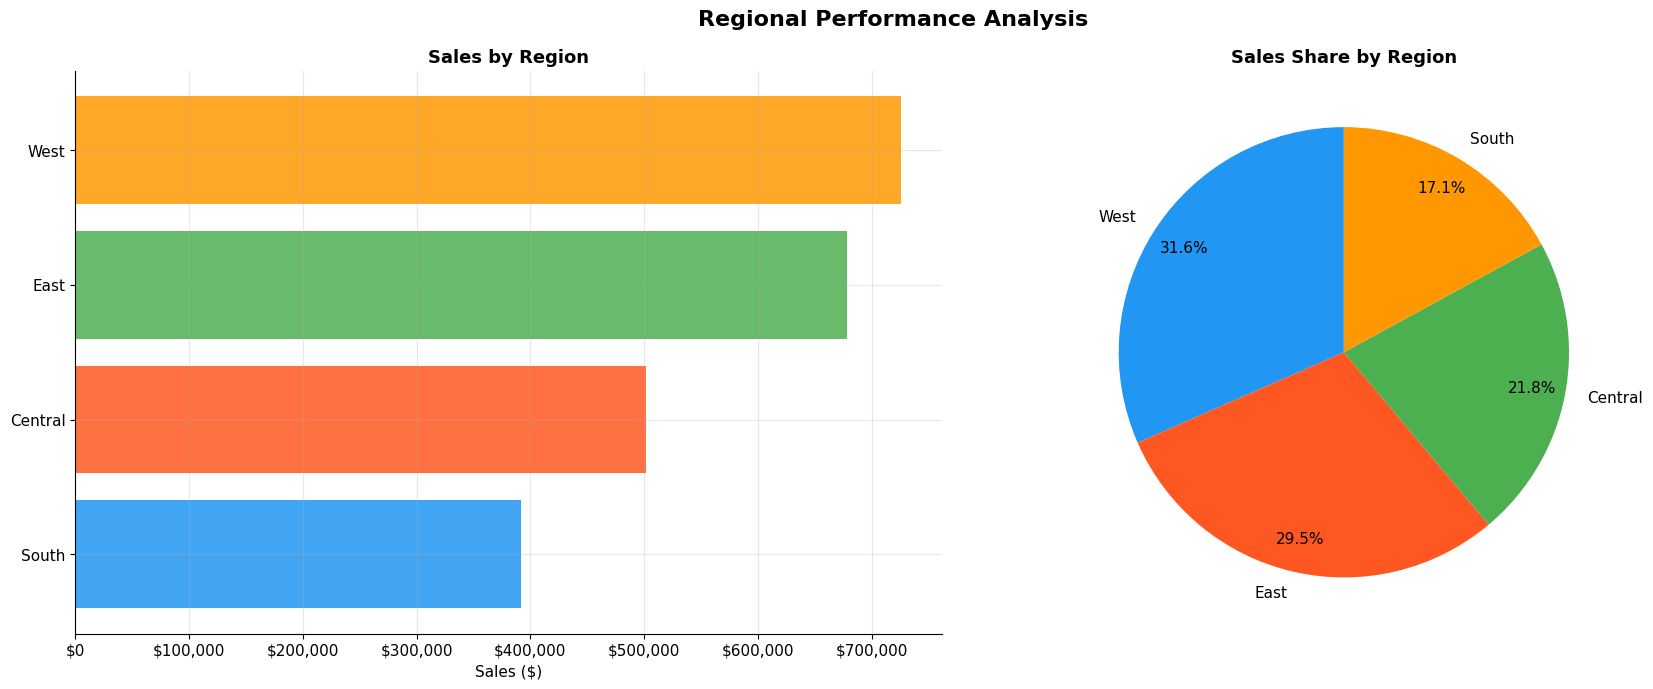


Regional Summary:
 region      Sales     Profit  Orders  Profit Margin %
   West 725,457.82 108,418.45    3203            14.90
   East 678,781.24  91,522.78    2848            13.50
Central 501,239.89  39,706.36    2323             7.90
  South 391,721.91  46,749.43    1620            11.90


In [8]:
# ── Sales by Region ────────────────────────────────────
region_col = 'region' if 'region' in df.columns else 'market'
region = df.groupby(region_col).agg(
    Sales   = ('sales',  'sum'),
    Profit  = ('profit', 'sum'),
    Orders  = ('order_id', 'count')
).reset_index().sort_values('Sales', ascending=False)

region['Profit Margin %'] = (region['Profit'] / region['Sales'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sales by region — horizontal bar
region_sorted = region.sort_values('Sales', ascending=True)
axes[0].barh(region_sorted[region_col], region_sorted['Sales'],
             color=COLORS[:len(region)], alpha=0.85)
axes[0].set_title('Sales by Region', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Sales ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Profit margin by region — pie chart
axes[1].pie(region['Sales'],
            labels=region[region_col],
            autopct='%1.1f%%',
            colors=COLORS[:len(region)],
            startangle=90,
            pctdistance=0.85)
axes[1].set_title('Sales Share by Region', fontweight='bold', fontsize=13)

plt.suptitle('Regional Performance Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/06_regional_analysis.png', dpi=150)
plt.show()

print('\nRegional Summary:')
print(region.to_string(index=False))

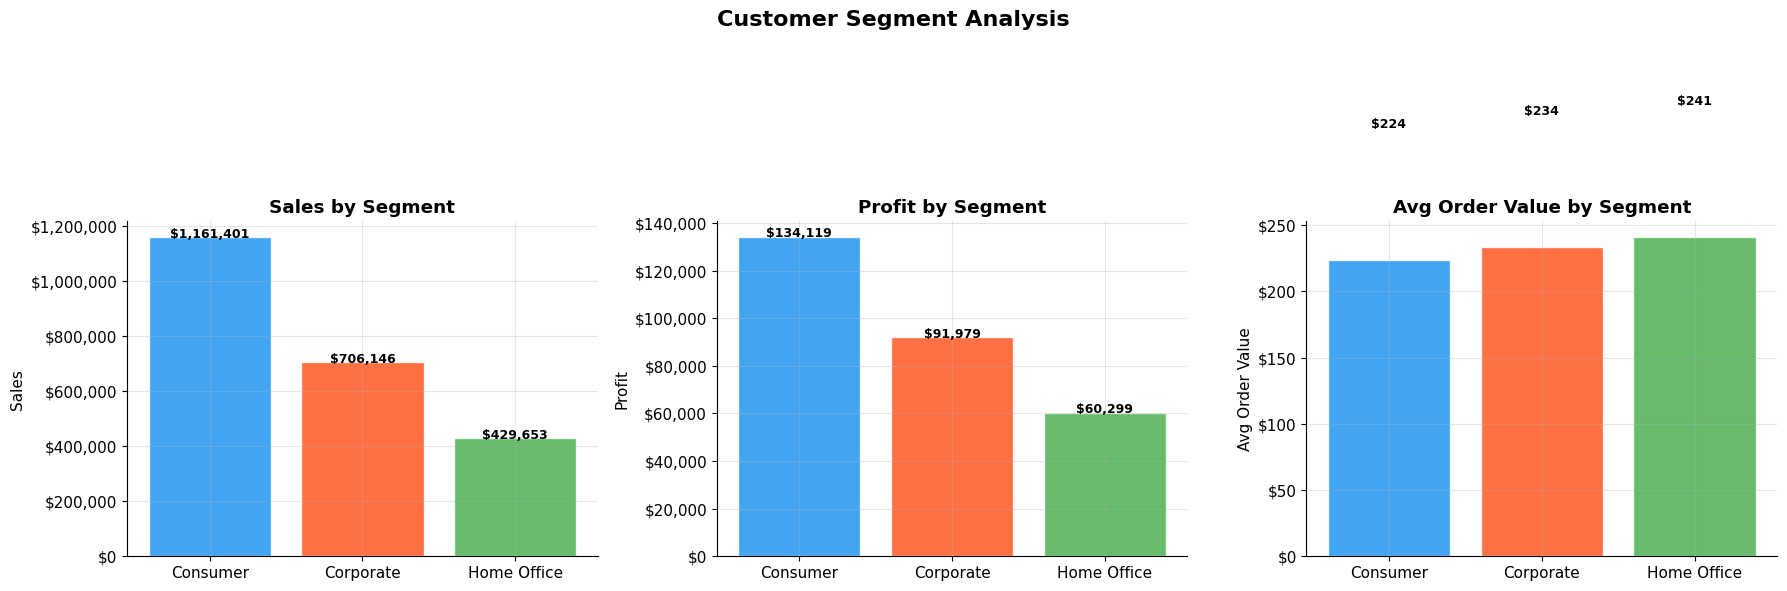


Segment Summary:
    segment        Sales     Profit  Orders  Customers  Profit Margin %  Avg Order Value
   Consumer 1,161,401.34 134,119.21    5191        409            11.50           223.73
  Corporate   706,146.37  91,979.13    3020        236            13.00           233.82
Home Office   429,653.15  60,298.68    1783        148            14.00           240.97


In [13]:
# ── Sales and Profit by Segment ────────────────────────
segment = df.groupby('segment').agg(
    Sales   = ('sales',  'sum'),
    Profit  = ('profit', 'sum'),
    Orders  = ('order_id', 'count'),
    Customers = ('customer_id', 'nunique') if 'customer_id' in df.columns else ('order_id','count')
).reset_index()

segment['Profit Margin %'] = (segment['Profit'] / segment['Sales'] * 100).round(1)
segment['Avg Order Value']  = (segment['Sales'] / segment['Orders']).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title, fmt in [
    (axes[0], 'Sales',           'Sales by Segment',            '${:,.0f}'),
    (axes[1], 'Profit',          'Profit by Segment',           '${:,.0f}'),
    (axes[2], 'Avg Order Value', 'Avg Order Value by Segment',  '${:,.0f}'),
]:
    bars = ax.bar(segment['segment'], segment[col],
                  color=COLORS[:3], alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    for bar, val in zip(bars, segment[col]):
        ax.text(bar.get_x()+bar.get_width()/2,
               bar.get_height()+100,
               fmt.format(val),
               ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/08_segment_analysis.png', dpi=150)
plt.show()

print('\nSegment Summary:')
print(segment.to_string(index=False))

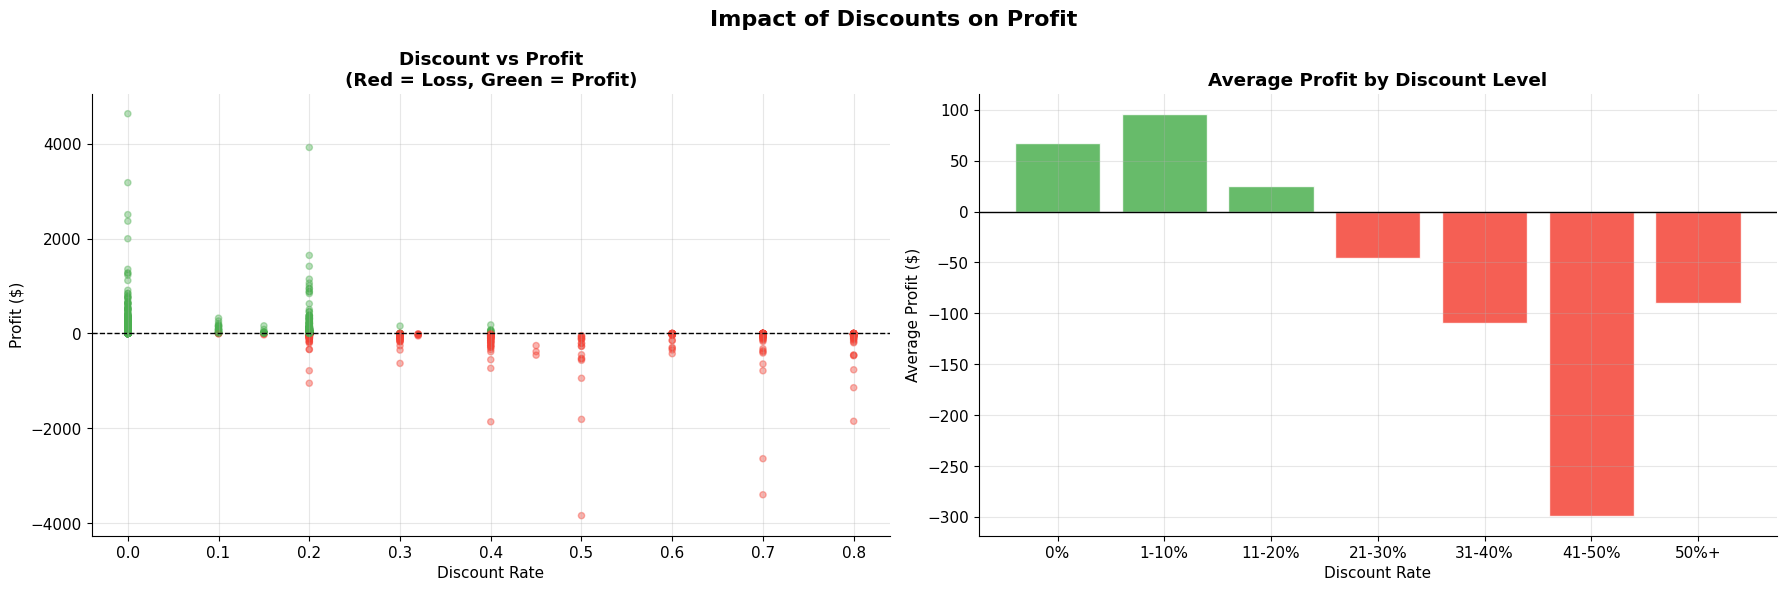


💡 KEY FINDING:
   Avg profit with NO discount   : $66.90
   Avg profit with >20% discount : $-97.18


In [14]:
# ── Scatter plot: Discount vs Profit ──────────────────
if 'discount' in df.columns:
    sample = df.sample(min(3000, len(df)), random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Scatter: discount vs profit
    scatter_colors = ['#F44336' if p < 0 else '#4CAF50' for p in sample['profit']]
    axes[0].scatter(sample['discount'], sample['profit'],
                    c=scatter_colors, alpha=0.4, s=20)
    axes[0].axhline(y=0, color='black', linewidth=1, linestyle='--')
    axes[0].set_title('Discount vs Profit\n(Red = Loss, Green = Profit)',
                      fontweight='bold')
    axes[0].set_xlabel('Discount Rate')
    axes[0].set_ylabel('Profit ($)')

    # Average profit by discount level
    df['discount_bucket'] = pd.cut(df['discount'],
        bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
        labels=['0%','1-10%','11-20%','21-30%','31-40%','41-50%','50%+'])
    disc_profit = df.groupby('discount_bucket')['profit'].mean().reset_index()

    bar_colors = ['#F44336' if v < 0 else '#4CAF50'
                  for v in disc_profit['profit']]
    axes[1].bar(disc_profit['discount_bucket'].astype(str),
                disc_profit['profit'],
                color=bar_colors, alpha=0.85, edgecolor='white')
    axes[1].axhline(y=0, color='black', linewidth=1)
    axes[1].set_title('Average Profit by Discount Level',
                      fontweight='bold')
    axes[1].set_xlabel('Discount Rate')
    axes[1].set_ylabel('Average Profit ($)')

    plt.suptitle('Impact of Discounts on Profit', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('charts/09_discount_analysis.png', dpi=150)
    plt.show()

    # Key finding
    loss_discount = df[df['discount'] > 0.2]['profit'].mean()
    no_discount   = df[df['discount'] == 0]['profit'].mean()
    print(f'\n💡 KEY FINDING:')
    print(f'   Avg profit with NO discount   : ${no_discount:,.2f}')
    print(f'   Avg profit with >20% discount : ${loss_discount:,.2f}')

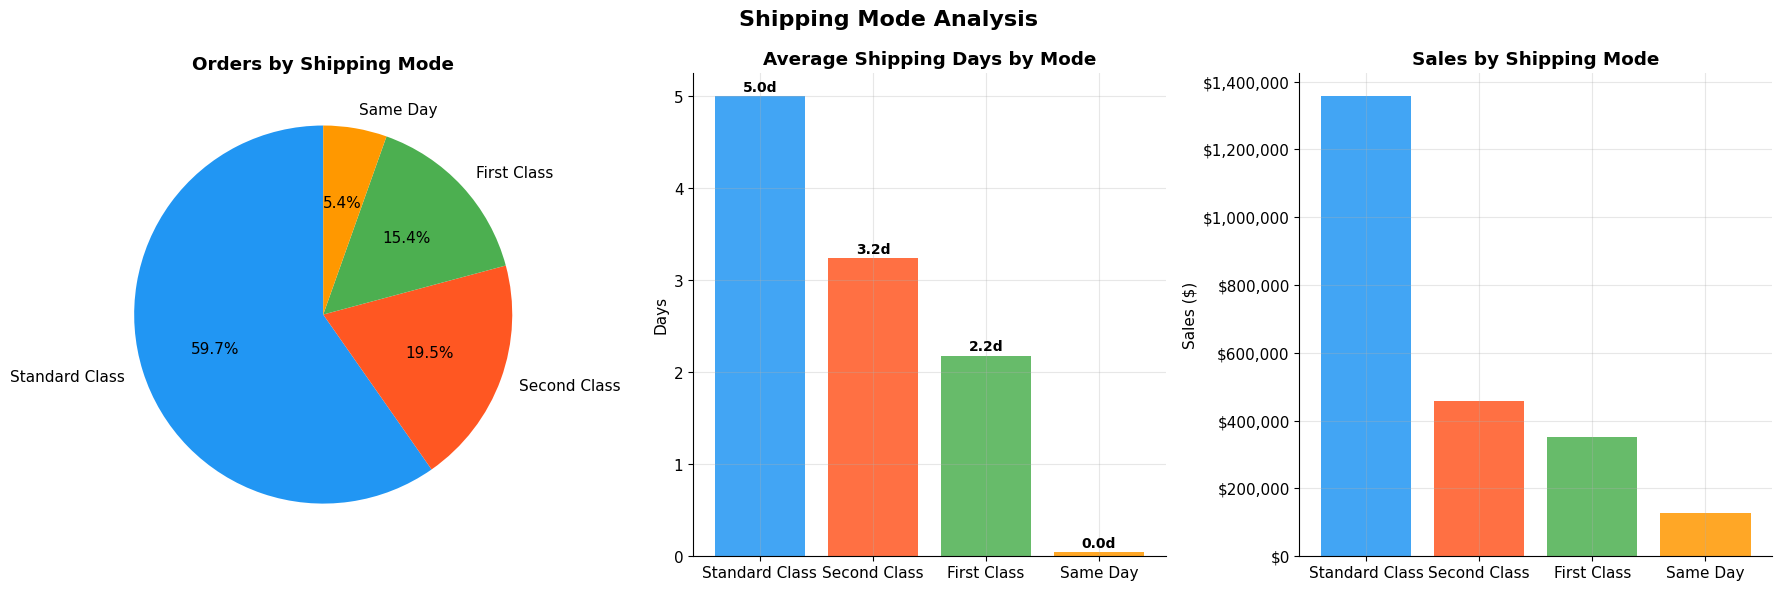


Shipping Summary:
     ship_mode  Orders  Avg_Ship_Days  Total_Sales  Shipping_Cost
Standard Class    5968           5.01 1,358,215.74           5968
  Second Class    1945           3.24   459,193.57           1945
   First Class    1538           2.18   351,428.42           1538
      Same Day     543           0.04   128,363.12            543


In [15]:
# ── Shipping Mode Analysis ─────────────────────────────
if 'ship_mode' in df.columns:
    ship = df.groupby('ship_mode').agg(
        Orders        = ('order_id', 'count'),
        Avg_Ship_Days = ('shipping_days', 'mean'),
        Total_Sales   = ('sales', 'sum'),
        Shipping_Cost = ('shipping_cost', 'sum') if 'shipping_cost' in df.columns
                         else ('sales', 'count')
    ).reset_index().sort_values('Orders', ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Orders by ship mode
    axes[0].pie(ship['Orders'], labels=ship['ship_mode'],
                autopct='%1.1f%%', colors=COLORS[:len(ship)], startangle=90)
    axes[0].set_title('Orders by Shipping Mode', fontweight='bold')

    # Average shipping days
    bars = axes[1].bar(ship['ship_mode'], ship['Avg_Ship_Days'],
                       color=COLORS[:len(ship)], alpha=0.85)
    axes[1].set_title('Average Shipping Days by Mode', fontweight='bold')
    axes[1].set_ylabel('Days')
    for bar, val in zip(bars, ship['Avg_Ship_Days']):
        axes[1].text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.05,
                    f'{val:.1f}d', ha='center', fontsize=10, fontweight='bold')

    # Sales by ship mode
    bars2 = axes[2].bar(ship['ship_mode'], ship['Total_Sales'],
                        color=COLORS[:len(ship)], alpha=0.85)
    axes[2].set_title('Sales by Shipping Mode', fontweight='bold')
    axes[2].set_ylabel('Sales ($)')
    axes[2].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    plt.suptitle('Shipping Mode Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('charts/10_shipping_analysis.png', dpi=150)
    plt.show()

    print('\nShipping Summary:')
    print(ship.to_string(index=False))

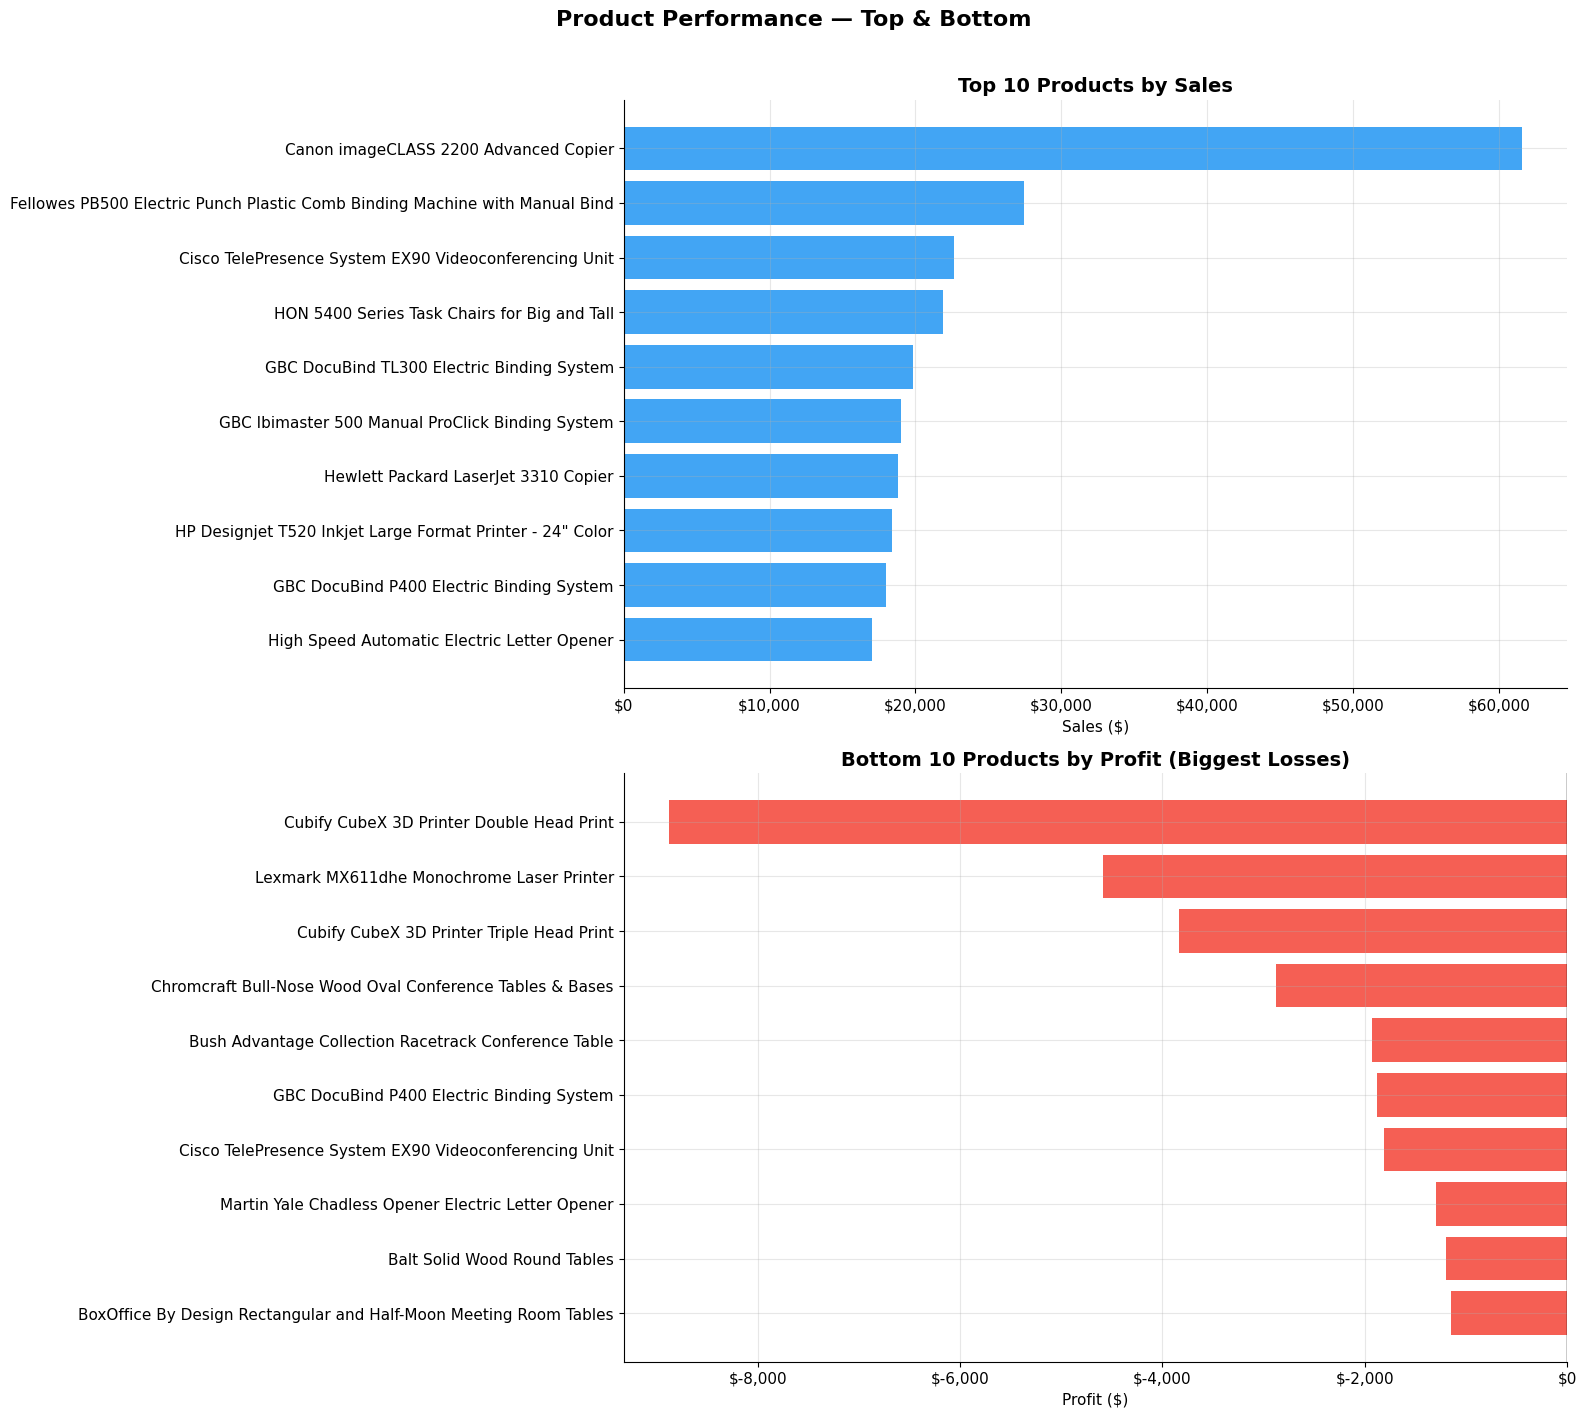

✅ Chart saved


In [16]:
# ── Top 10 and Bottom 10 Products ─────────────────────
if 'product_name' in df.columns:
    products = df.groupby('product_name').agg(
        Sales  = ('sales',  'sum'),
        Profit = ('profit', 'sum'),
        Orders = ('order_id', 'count')
    ).reset_index()

    top10    = products.nlargest(10,  'Sales')
    bottom10 = products.nsmallest(10, 'Profit')

    fig, axes = plt.subplots(2, 1, figsize=(16, 14))

    # Top 10 by sales
    top10_s = top10.sort_values('Sales')
    axes[0].barh(top10_s['product_name'], top10_s['Sales'],
                 color='#2196F3', alpha=0.85)
    axes[0].set_title('Top 10 Products by Sales', fontweight='bold', fontsize=14)
    axes[0].set_xlabel('Sales ($)')
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    # Bottom 10 by profit (biggest losses)
    bottom10_s = bottom10.sort_values('Profit', ascending=False)
    axes[1].barh(bottom10_s['product_name'], bottom10_s['Profit'],
                 color='#F44336', alpha=0.85)
    axes[1].axvline(x=0, color='black', linewidth=1)
    axes[1].set_title('Bottom 10 Products by Profit (Biggest Losses)',
                      fontweight='bold', fontsize=14)
    axes[1].set_xlabel('Profit ($)')
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    plt.suptitle('Product Performance — Top & Bottom', fontsize=16,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('charts/11_top_bottom_products.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Chart saved')

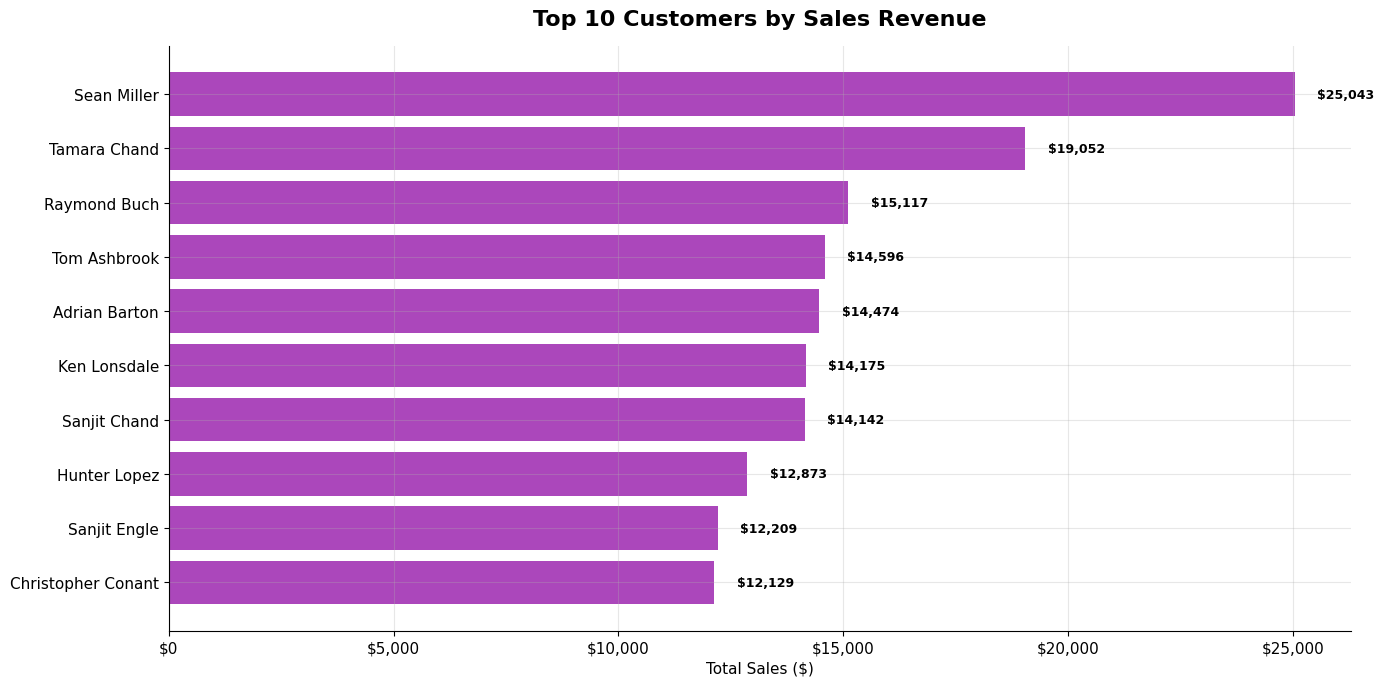

✅ Chart saved


In [17]:
# ── Top 10 Customers by Sales ──────────────────────────
if 'customer_name' in df.columns:
    top_customers = df.groupby('customer_name').agg(
        Sales  = ('sales',  'sum'),
        Profit = ('profit', 'sum'),
        Orders = ('order_id', 'nunique')
    ).reset_index().nlargest(10, 'Sales').sort_values('Sales')

    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.barh(top_customers['customer_name'],
                   top_customers['Sales'],
                   color='#9C27B0', alpha=0.85)

    for bar, val in zip(bars, top_customers['Sales']):
        ax.text(bar.get_width() + 500,
               bar.get_y() + bar.get_height()/2,
               f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

    ax.set_title('Top 10 Customers by Sales Revenue',
                 fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Total Sales ($)')
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    plt.tight_layout()
    plt.savefig('charts/12_top_customers.png', dpi=150)
    plt.show()
    print('✅ Chart saved')

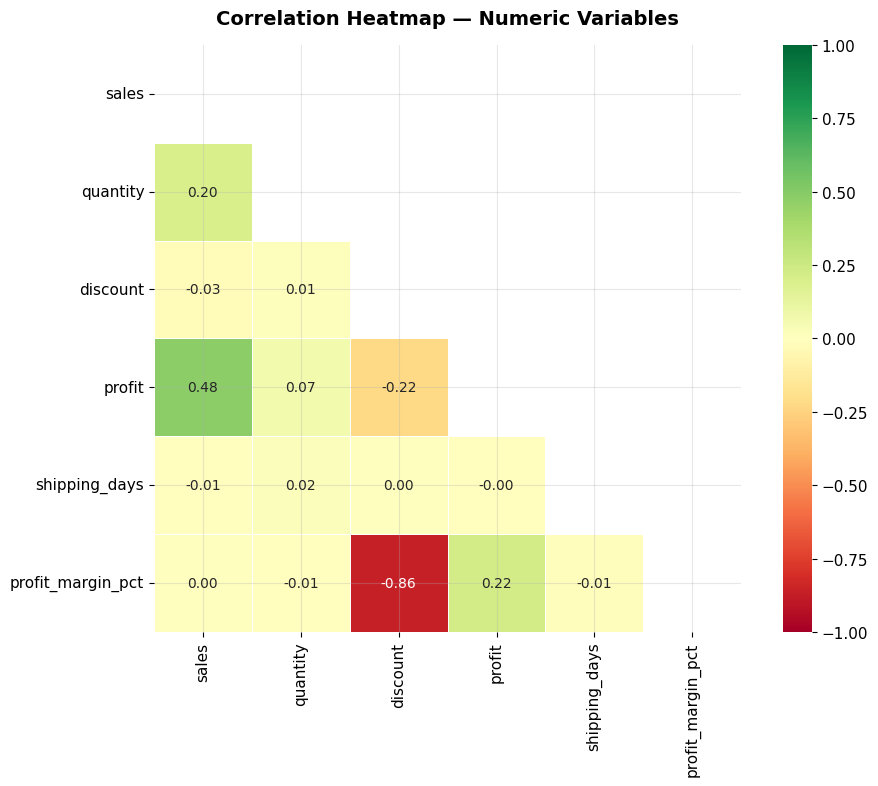


💡 Key correlations to note:
   Discount vs Profit  : -0.219
   Sales vs Profit     : 0.479


In [18]:
# ── Correlation between numeric columns ───────────────
num_cols = ['sales', 'quantity', 'discount', 'profit',
            'shipping_cost', 'shipping_days', 'profit_margin_pct']
num_cols = [c for c in num_cols if c in df.columns]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Correlation Heatmap — Numeric Variables',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('charts/13_correlation_heatmap.png', dpi=150)
plt.show()

print('\n💡 Key correlations to note:')
print('   Discount vs Profit  :', round(corr_matrix.loc['discount','profit'], 3))
print('   Sales vs Profit     :', round(corr_matrix.loc['sales','profit'], 3))
if 'shipping_cost' in corr_matrix.columns:
    print('   Sales vs Ship Cost  :', round(corr_matrix.loc['sales','shipping_cost'], 3))

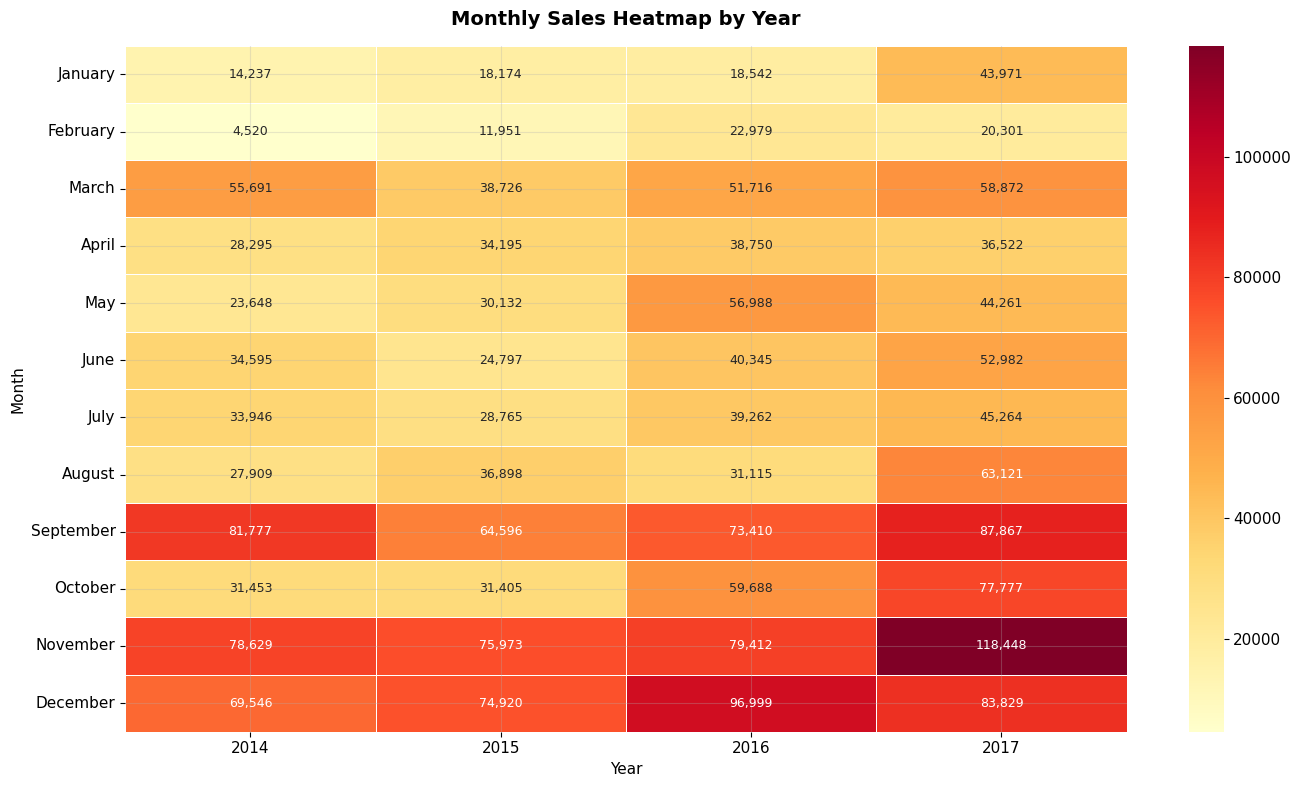

✅ Calendar heatmap saved


In [19]:
# ── Sales heatmap by Month and Year ───────────────────
pivot = df.pivot_table(
    values='sales',
    index='order_month_name',
    columns='order_year',
    aggfunc='sum'
)

# Sort months correctly Jan to Dec
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot = pivot.reindex([m for m in month_order if m in pivot.index])

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot, annot=True, fmt=',.0f',
    cmap='YlOrRd', linewidths=0.5,
    ax=ax, annot_kws={'size': 9}
)
ax.set_title('Monthly Sales Heatmap by Year',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Month')
plt.tight_layout()
plt.savefig('charts/14_monthly_heatmap.png', dpi=150)
plt.show()
print('✅ Calendar heatmap saved')

In [23]:
# ── Auto-generate business insights ───────────────────
best_category  = category.loc[category['Sales'].idxmax(), 'category']
worst_category = category.loc[category['Profit'].idxmin(), 'category']
best_region    = region.loc[region['Sales'].idxmax(), region_col]
best_segment   = segment.loc[segment['Sales'].idxmax(), 'segment']

loss_products = sub_cat[sub_cat['Profit'] < 0]['sub_category'].tolist()

print('=' * 60)
print('         📋 KEY BUSINESS INSIGHTS')
print('=' * 60)
print(f'\n💰 REVENUE')
print(f'   Total Sales          : ${total_sales:,.2f}')
print(f'   Total Profit         : ${total_profit:,.2f}')
print(f'   Overall Margin       : {profit_margin:.1f}%')
print(f'   Total Orders         : {total_orders:,}')

print(f'\n🏆 TOP PERFORMERS')
print(f'   Best Category        : {best_category}')
print(f'   Best Region          : {best_region}')
print(f'   Best Segment         : {best_segment}')

print(f'\n⚠️  PROBLEM AREAS')
print(f'   Worst Category       : {worst_category}')
if loss_products:
    print(f'   Loss-making Sub-cats : {", ".join(loss_products)}')

print(f'\n📦 OPERATIONS')
print(f'   Avg Shipping Days    : {avg_shipping:.1f} days')
print(f'   Avg Discount Given   : {avg_discount:.1f}%')
print(f'   Avg Order Value      : ${avg_order_value:,.2f}')

print(f'\n💡 RECOMMENDATIONS')
print(f'   1. Reduce discounts above 20% — they consistently cause losses')
print(f'   2. Investigate loss-making sub-categories: {", ".join(loss_products) if loss_products else "None"}')
print(f'   3. Focus marketing on {best_region} — highest revenue region')
print(f'   4. Prioritise {best_segment} segment — highest spending customers')
print(f'   5. Q4 typically strongest — plan stock and campaigns accordingly')
print('=' * 60)

         📋 KEY BUSINESS INSIGHTS

💰 REVENUE
   Total Sales          : $2,297,200.86
   Total Profit         : $286,397.02
   Overall Margin       : 12.5%
   Total Orders         : 5,009

🏆 TOP PERFORMERS
   Best Category        : Technology
   Best Region          : West
   Best Segment         : Consumer

⚠️  PROBLEM AREAS
   Worst Category       : Furniture
   Loss-making Sub-cats : Supplies, Bookcases, Tables

📦 OPERATIONS
   Avg Shipping Days    : 4.0 days
   Avg Discount Given   : 15.6%
   Avg Order Value      : $458.61

💡 RECOMMENDATIONS
   1. Reduce discounts above 20% — they consistently cause losses
   2. Investigate loss-making sub-categories: Supplies, Bookcases, Tables
   3. Focus marketing on West — highest revenue region
   4. Prioritise Consumer segment — highest spending customers
   5. Q4 typically strongest — plan stock and campaigns accordingly


In [24]:
# ── Save insights summary to CSV ──────────────────────
insights = pd.DataFrame({
    'Metric'  : ['Total Sales','Total Profit','Profit Margin %',
                 'Total Orders','Best Category','Best Region',
                 'Best Segment','Avg Shipping Days','Avg Discount %',
                 'Avg Order Value'],
    'Value'   : [f'${total_sales:,.2f}', f'${total_profit:,.2f}',
                 f'{profit_margin:.1f}%', f'{total_orders:,}',
                 best_category, best_region, best_segment,
                 f'{avg_shipping:.1f} days', f'{avg_discount:.1f}%',
                 f'${avg_order_value:,.2f}']
})

insights.to_csv('EDA_Key_Insights.csv', index=False)
print('✅ Key insights saved to EDA_Key_Insights.csv')

# List all saved charts
print('\n📁 Charts saved in the charts/ folder:')
for f in sorted(os.listdir('charts')):
    print(f'   {f}')

print('\n🎉 EDA Complete!')
print('   Next step → 03_RFM_Segmentation.ipynb')

✅ Key insights saved to EDA_Key_Insights.csv

📁 Charts saved in the charts/ folder:
   04_category_analysis.png
   05_subcategory_analysis.png
   06_regional_analysis.png
   07_top10_countries.png
   08_segment_analysis.png
   09_discount_analysis.png
   10_shipping_analysis.png
   11_top_bottom_products.png
   12_top_customers.png
   13_correlation_heatmap.png
   14_monthly_heatmap.png

🎉 EDA Complete!
   Next step → 03_RFM_Segmentation.ipynb
